# **1. Perkenalan Dataset (Rice Cammeo and Osmancik)**
Dataset ini berisi fitur morfologi dari 3810 butir beras yang terbagi dalam dua kelas: Cammeo dan Osmancik. Fitur mencakup Area, Perimeter, Panjang Sumbu Utama, dll.

**Sumber Dataset:** [UCI Machine Learning Repository - Rice (Cammeo and Osmancik)](https://archive.ics.uci.edu/dataset/545/rice+cammeo+and+osmancik)

# **2. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

In [2]:
# Memuat dataset Rice dari file CSV
df = pd.read_csv('../rice_dataset.csv')

print('=== 5 Baris Pertama Dataset ===')
print(df.head())

print('\n=== Informasi Dataset ===')
df.info()

print('\n=== Statistik Deskriptif ===')
print(df.describe())

=== 5 Baris Pertama Dataset ===
    Area   Perimeter  Major_Axis_Length  Minor_Axis_Length  Eccentricity  \
0  15231  525.578979         229.749878          85.093788      0.928882   
1  14656  494.311005         206.020065          91.730972      0.895405   
2  14634  501.122009         214.106781          87.768288      0.912118   
3  13176  458.342987         193.337387          87.448395      0.891861   
4  14688  507.166992         211.743378          89.312454      0.906691   

   Convex_Area    Extent   Class  
0        15617  0.572896  Cammeo  
1        15072  0.615436  Cammeo  
2        14954  0.693259  Cammeo  
3        13368  0.640669  Cammeo  
4        15262  0.646024  Cammeo  

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               3810 non-null   int64  
 1   Perimeter          

# **4. Exploratory Data Analysis (EDA)**

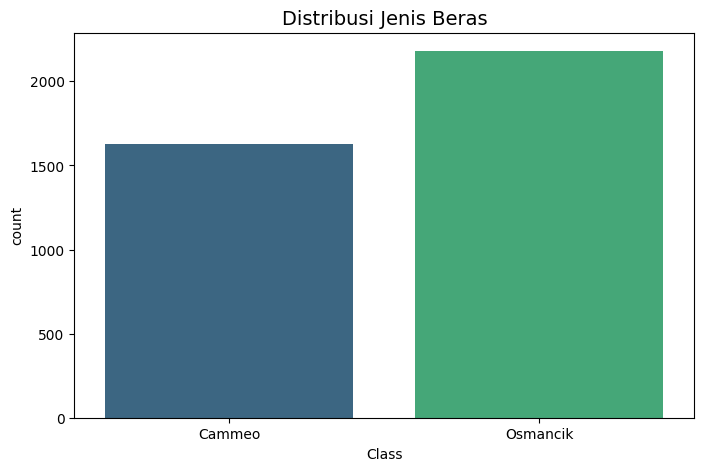


Distribusi Kelas:
Class
Osmancik    2180
Cammeo      1630
Name: count, dtype: int64


In [3]:
# 1. Distribusi target variable (Class)
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Distribusi Jenis Beras', fontsize=14)
plt.show()

print('\nDistribusi Kelas:')
print(df['Class'].value_counts())

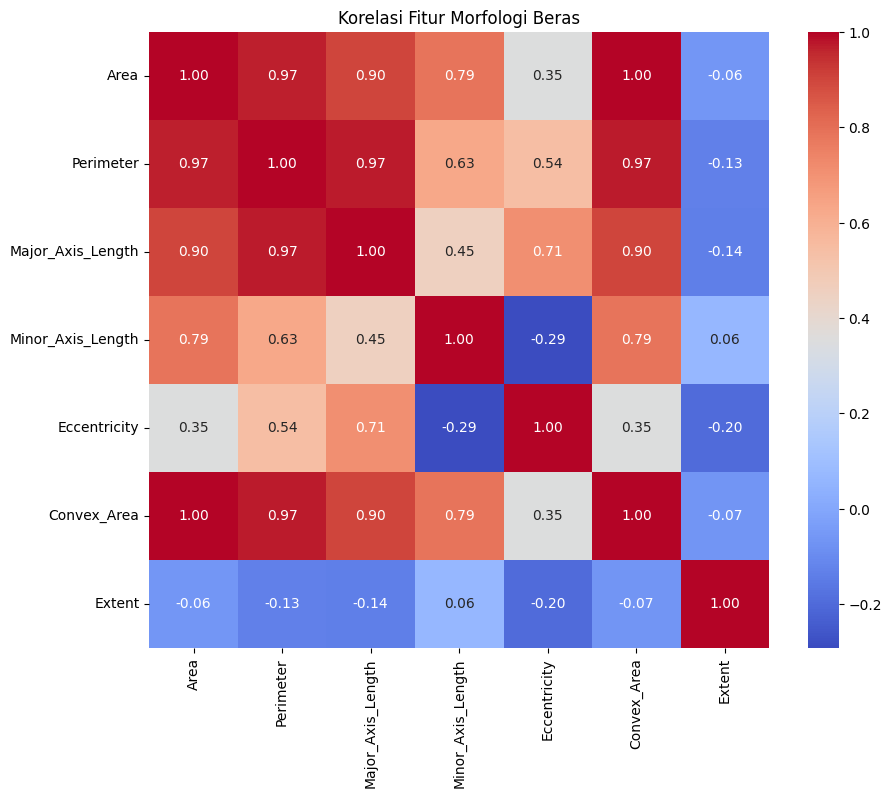

In [4]:
# 2. Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_df = df.drop(columns=['Class'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Fitur Morfologi Beras')
plt.show()

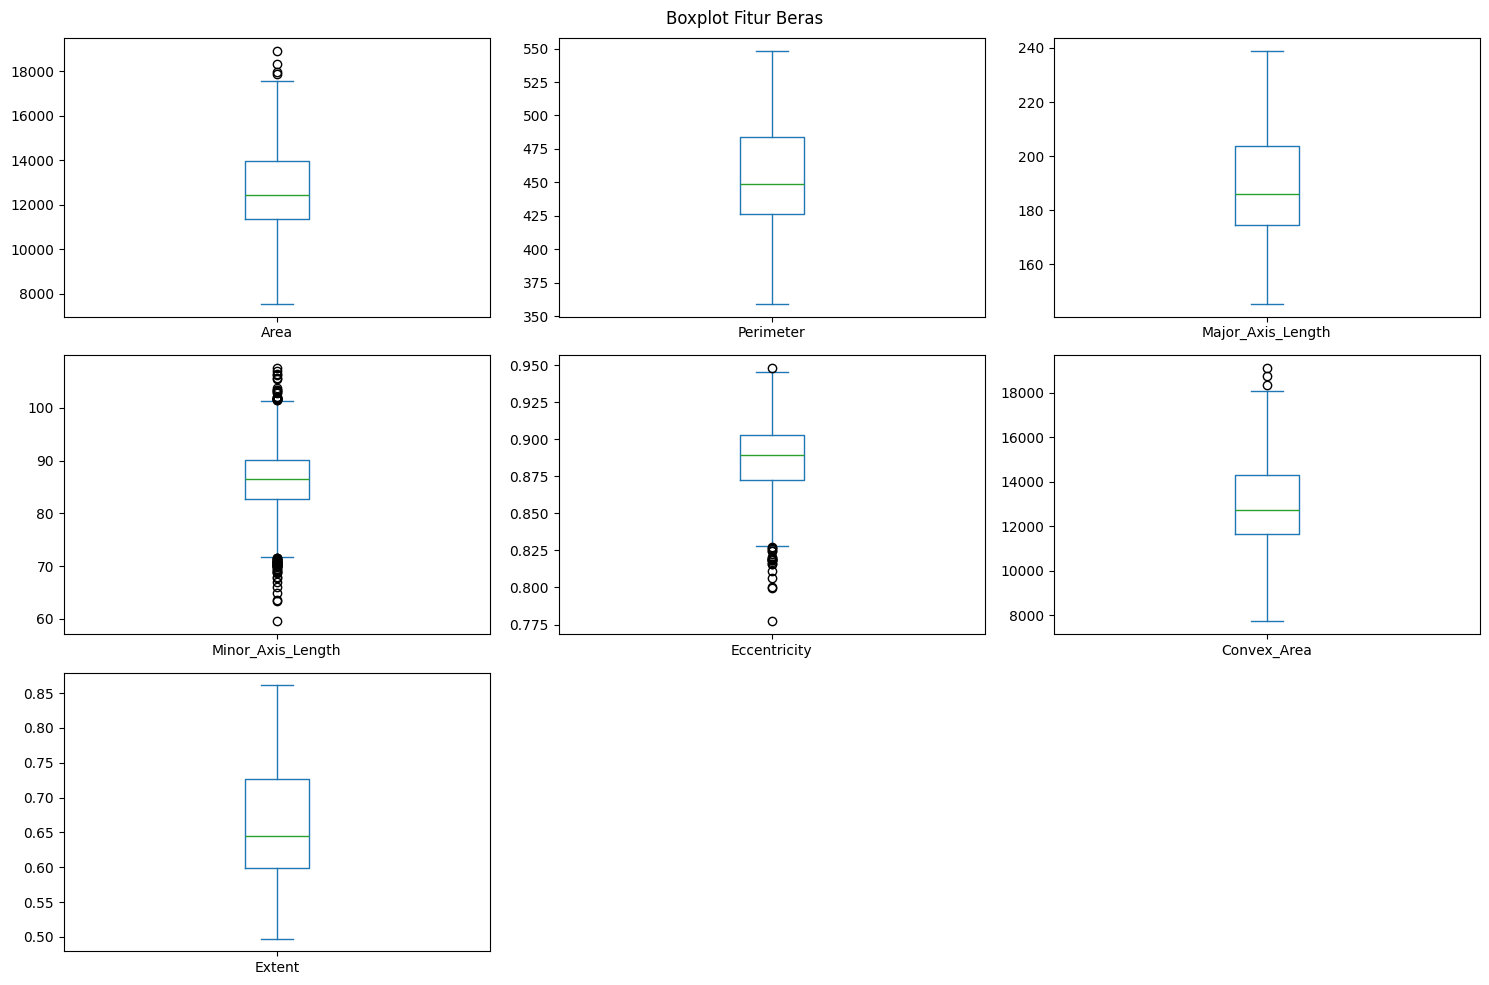

In [5]:
# 3. Boxplot untuk deteksi outlier awal
df.plot(kind='box', subplots=True, layout=(3,3), figsize=(15,10), title='Boxplot Fitur Beras')
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

In [6]:
# 1. Label Encoding Target (Cammeo=0, Osmancik=1)
df['Class'] = df['Class'].map({'Cammeo': 0, 'Osmancik': 1})

# 2. Menghapus Outlier dengan IQR
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]
    
print(f'Jumlah data setelah pembersihan: {df.shape[0]}')

Jumlah data setelah pembersihan: 3724


In [7]:
# 3. Scaling & Split
X = df.drop('Class', axis=1)
y = df['Class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}')

Train size: 2979, Test size: 745


# **9. Menyimpan Dataset Hasil Preprocessing**
Sesuai kriteria basic, dataset yang telah diproses disimpan ke dalam file CSV agar dapat digunakan untuk tahap pemodelan.

In [8]:
# Menyimpan hasil preprocessing ke file CSV
train_data = pd.DataFrame(X_train, columns=X.columns)
train_data['Class'] = y_train.values

test_data = pd.DataFrame(X_test, columns=X.columns)
test_data['Class'] = y_test.values

# Membuat folder output jika belum ada
import os
os.makedirs('namadataset_preprocessing', exist_ok=True)

train_data.to_csv('namadataset_preprocessing/rice_preprocessing_train.csv', index=False)
test_data.to_csv('namadataset_preprocessing/rice_preprocessing_test.csv', index=False)

print('✅ Dataset berhasil disimpan di folder namadataset_preprocessing/')

✅ Dataset berhasil disimpan di folder namadataset_preprocessing/
